Data set - German Credit Risk
11 columns
6 - categorical 
5 numerical
1000  rows

Raw Data → Cleaning → Analysis (EDA) → Feature Engineering → Model Training → Evaluation → Save Model → Web App

EDA - process of analyzing and understanding your dataset using statistics and visual methods before building a machine learning model.


Input: Customer details (age, job, income behaviour, etc.)
Output:

GOOD → safe to give loan
BAD → risky customer

In [ ]:
# 1. Pandas - organize and clean data
import pandas as pd
# 2. NumPy - prepare numerical data
import numpy as np
# 3. Matplotlib/Seaborn - visualize results
import matplotlib.pyplot as plt
import seaborn as sns

A DataFrame is a 2-dimensional table (like Excel sheet) used in Python for storing and working with data. It is the main data structure in the Pandas library.

In [9]:
# Display setting
pd.set_option('display.max_columns', None)

In [10]:
sns.set_style('whitegrid')

In [11]:
# Load data
df = pd.read_csv('german_credit_data.csv')

In [12]:
# Check data load successfully
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


pandas is giving unique value column - remove the column called - Unnamed column

In [13]:
# How age value distribution
df['Age'].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [14]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [15]:
df.shape

(1000, 11)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 115.1 KB


We can see saving account and checking account have NA values 
Need to drop these rows

In [17]:
# Statistical summary
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [18]:
# also getting categorical data like above. T- transpose
df.describe(include = "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df["Job"].unique()

array([2, 1, 3, 0])

In [20]:
# Get missing values
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [21]:
# Check duplicated rows
df.duplicated().sum()

np.int64(0)

In [22]:
# Drop missing values
df = df.dropna().reset_index(drop=True)

In [23]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


Now have 522 rows and 11 columns only 

In [24]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [25]:
# Remove Unnamed column - because already have unique column 
df.drop(columns = 'Unnamed: 0', inplace=True)

In [26]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

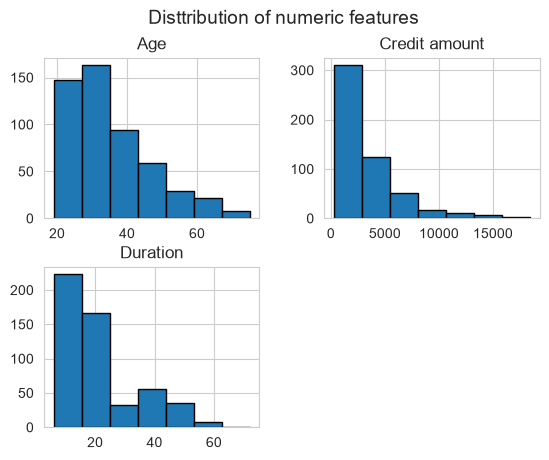

In [27]:
df[["Age", "Credit amount", "Duration"]].hist(bins = 7, edgecolor = 'black')
plt.suptitle("Disttribution of numeric features", fontsize = 14)
plt.show()

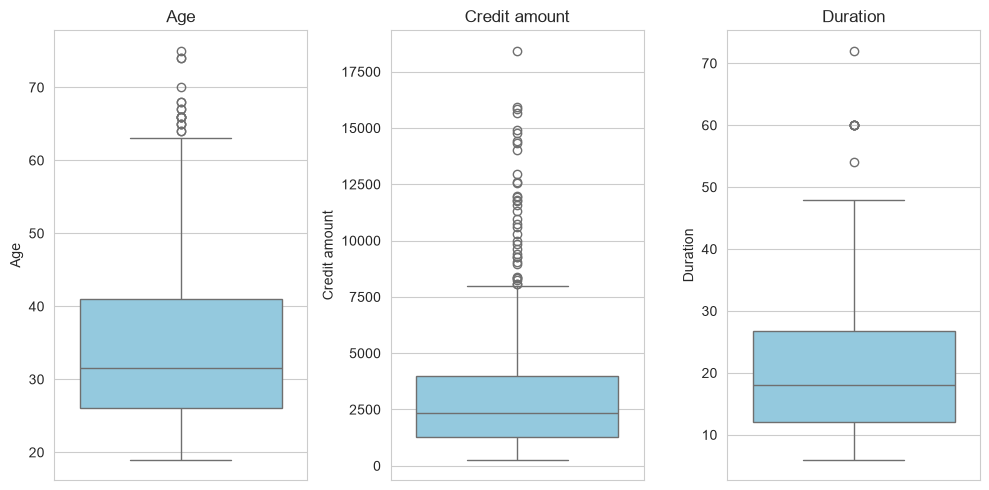

In [28]:
plt.figure(figsize = (10, 5))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y = df[col], color = 'skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [29]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [30]:
categorical_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

In [31]:
import warnings
warnings.filterwarnings("ignore")

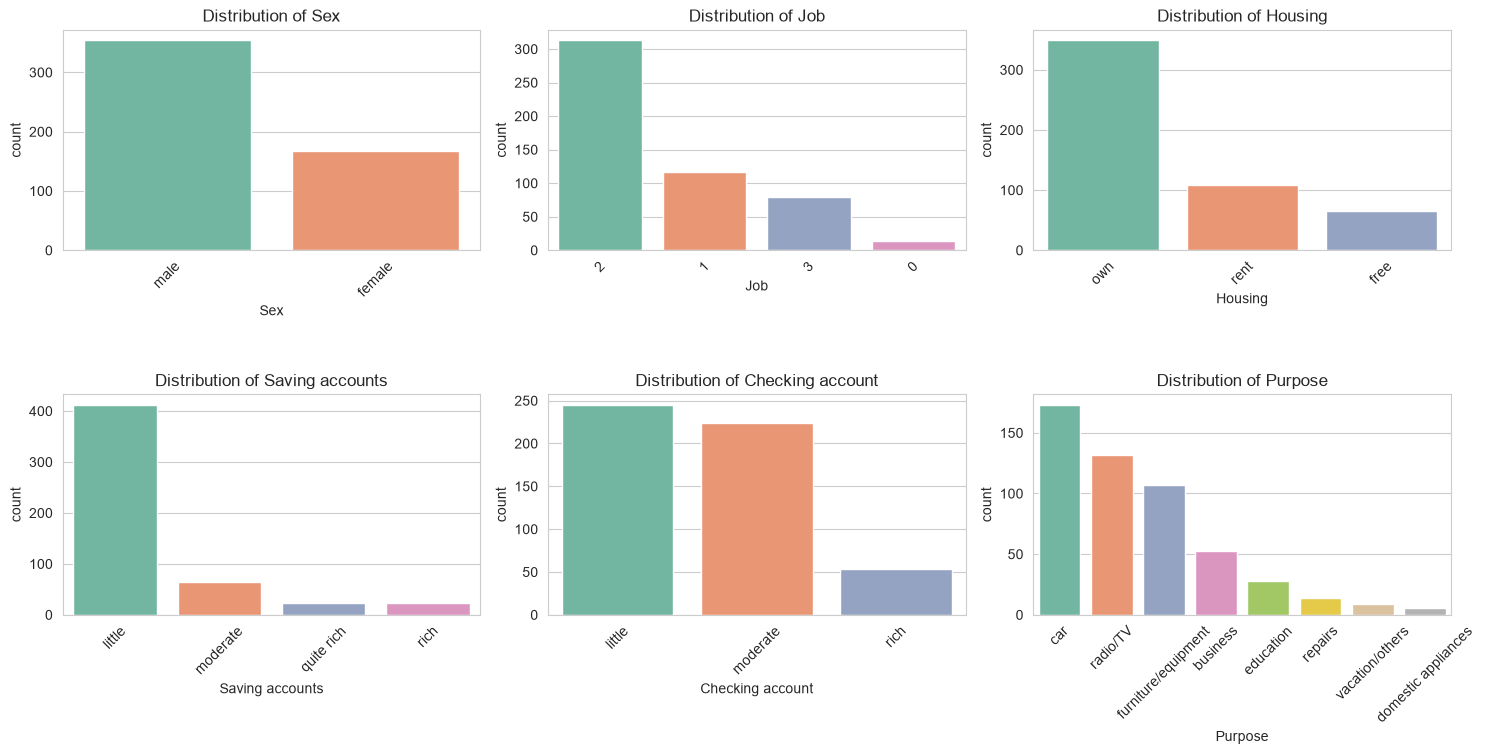

In [32]:
plt.figure(figsize = (15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data = df, x = col, palette = "Set2", order = df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()


In [33]:
corr = df[["Age", "Job", "Credit amount", "Duration"]].corr()

In [34]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


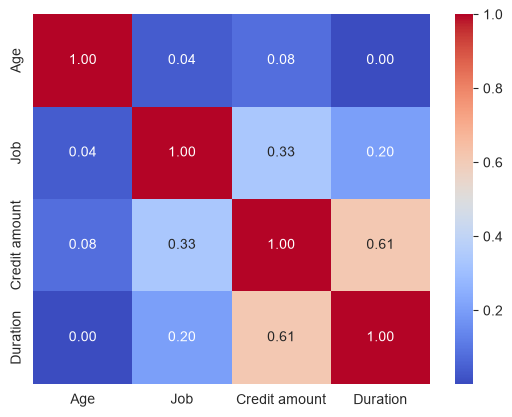

In [35]:
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.show()

no strong correlations
credit amount and duration have 0.6
if creadit amount increases duration increasing together 
people are looking for more duration

In [36]:
df.groupby("Job")["Credit amount"].mean()

# This tells us: "On average, how much credit/loan amount do people in each job  category tend to borrow?"
# Job is usually encoded as: 0 = unskilled non-resident, 1 = unskilled resident, 2 = skilled, 3 = highly skilled/management.
# Expectation: higher job skill level -> higher average credit amount borrowed,
# since more skilled/senior roles often mean higher income and bigger loans (e.g. 
# business, property, large purchases)

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [37]:
df.groupby("Sex")["Credit amount"].mean()

# by gender wise, male is asking for more credit amount

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [38]:
pd.pivot_table(df, values = "Credit amount", index = "Housing", columns = "Purpose")

# Average credit amount by Housing type and Loan Purpose
# Rows = Housing (own/rent/free), Columns = Purpose (car, education, etc.)
# Housing- loan applicant's living situation
# own: applicant owns their home
# rent: applicant pays rent
# free: applicant lives rent-free (e.g., with family, employer-provided housing)

# rent-houses people take more loan for buiness purposes

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


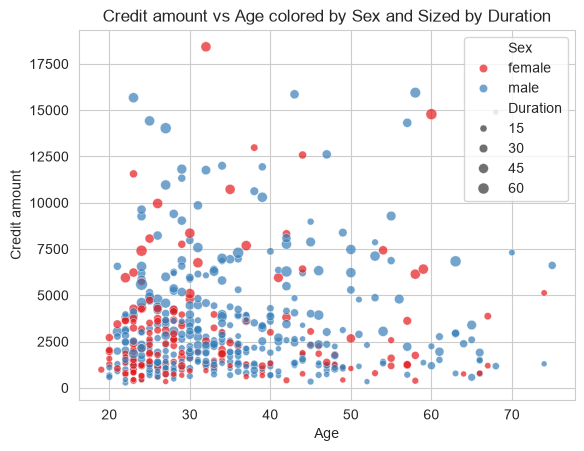

In [39]:
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex", size = "Duration", alpha=0.7, palette='Set1')
plt.xlabel("Age")
plt.ylabel("Credit amount")
plt.title("Credit amount vs Age colored by Sex and Sized by Duration")
plt.show()

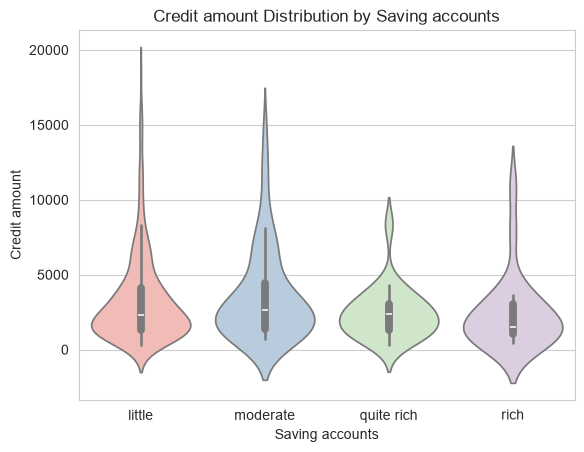

In [40]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette = "Pastel1")
plt.title("Credit amount Distribution by Saving accounts")
plt.show()

# Saving accounts vs Credit amount:
# - Typical (median) loan size is about the SAME for all groups (~2000-3000)
# - But "little"/"moderate" savers sometimes take HUGE loans (up to 20000) -> wide spread
# - "rich" savers rarely go above ~13500, most stay small (<5000) -> narrow spread
# Meaning: low savings doesn't mean bigger loans on average,
# it means MORE UNPREDICTABLE loan sizes (bigger range, more big outliers)

In [41]:
df["Risk"].value_counts(normalize = True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

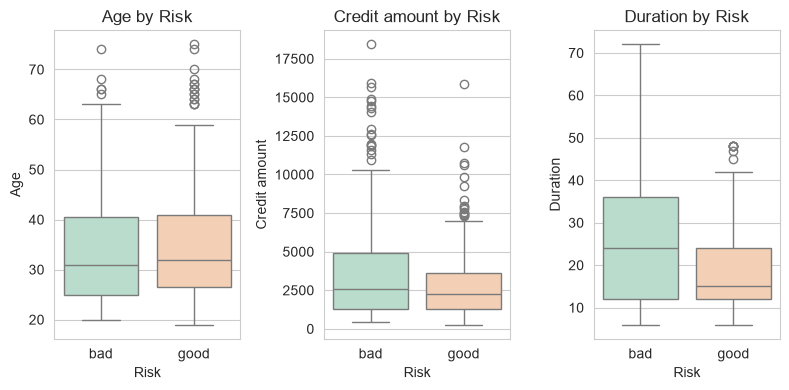

In [42]:
plt.figure(figsize=(8, 4))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2")
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [43]:
df.groupby ("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [44]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

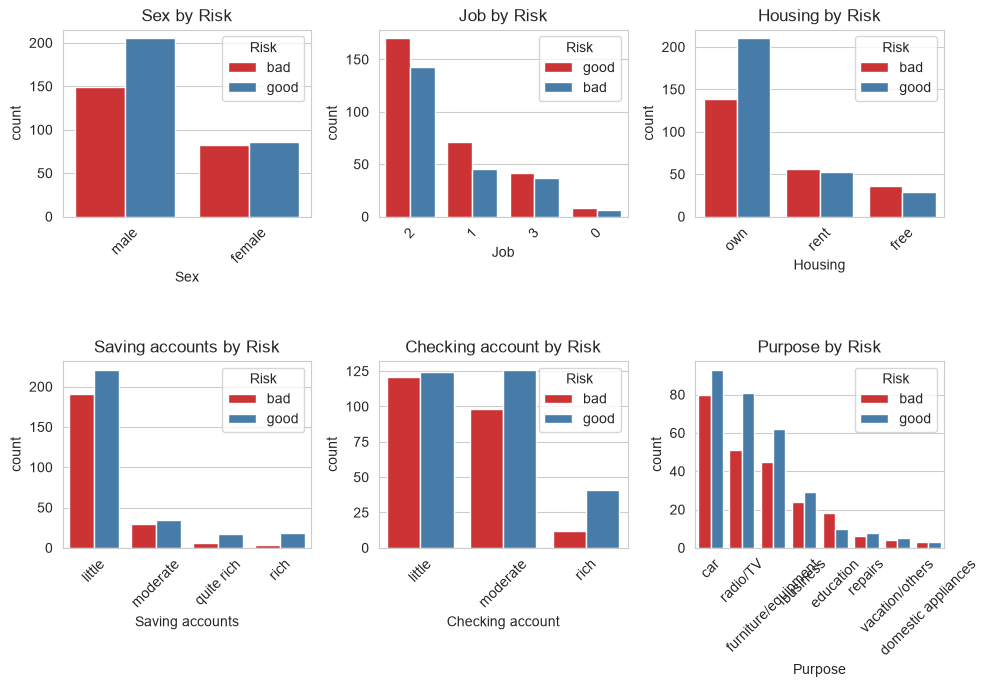

In [125]:
plt.figure(figsize=(10, 9))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=df, x=col, hue="Risk", palette="Set1", order = df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [47]:
features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account", "Credit amount", "Duration"]

In [48]:
target = "Risk"

In [49]:
df_model = df[features + [target]].copy()

In [50]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [51]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [52]:
cat_cols = df_model.select_dtypes(include=["object"]).columns.drop("Risk")


In [53]:
le_dict = {}

In [54]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [55]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

In [56]:
le_target = LabelEncoder()
 

In [57]:
target

'Risk'

In [58]:
df_model[target] = le_target.fit_transform(df_model[target])

In [59]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [60]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [61]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X = df_model.drop(target, axis = 1)

In [64]:
y = df_model[target]

In [65]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [66]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


In [68]:
X_train.shape

(417, 8)

In [69]:
X_test.shape

(105, 8)

In [92]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV



In [94]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_


In [95]:
dt = DecisionTreeClassifier(random_state=1, class_weight = "balanced")
dt_param_grid = {
    "max_depth": [3,5,7,10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


In [100]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [101]:
print("Decision Tree Accuracy: ", acc_dt)


Decision Tree Accuracy:  0.5238095238095238


In [102]:
print("Best parameters", params_dt)

Best parameters {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [103]:
rf = RandomForestClassifier(random_state=1, class_weight = "balanced", n_jobs = -1)


In [104]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3,5,7,10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [105]:
best_rf, acc_rf,params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)


In [106]:
print("Random Forest Accuracy: ", acc_rf)


Random Forest Accuracy:  0.5904761904761905


In [107]:
print("Best parameters", params_rf)

Best parameters {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [108]:
et = ExtraTreesClassifier(random_state=1, class_weight = "balanced", n_jobs = -1)

In [109]:
et_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3,5,7,10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [110]:
best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [111]:
print("Extra Trees Accuracy: ", acc_et)

Extra Trees Accuracy:  0.49523809523809526


In [112]:
print("Best parameters", params_et)

Best parameters {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [113]:
xgb = XGBClassifier(random_state = 1, scale_pos_weight = (y_train==0).sum()/(y_train==1).sum( ), use_label_encoder = False, eval_metric = "logloss")

In [114]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3,5,7],
    "learning_rate" : [0.01, 0.1, 0.2],
    "subsample": [0.7, 1],
    "colsample_bytree": [0.7, 1]

}

In [115]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

In [116]:
print("XGB accuracy", acc_xgb)

XGB accuracy 0.580952380952381


In [117]:
print("Best parameters", params_xgb)

Best parameters {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}


In [119]:
best_et.predict(X_test)

array([1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0])

In [120]:
joblib.dump(best_et, "extra_trees_credit_model.pkl") 

['extra_trees_credit_model.pkl']

In [124]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')